In [2]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split, TensorDataset
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping
import torch.nn.functional as F
import matplotlib.pyplot as plt
import my_bar
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import importlib
importlib.reload(my_bar)

<module 'my_bar' from '/Users/piotrblaszyk/Documents/university/MRIGI/group-project-70006/code/my_bar.py'>

In [ ]:
x_numpy, y_numpy = my_bar.load_experimental_data()

x_numpy shape: (1138, 10)
y_numpy shape: (1138, 2)


In [5]:
x_normalized, x_means, x_stds = my_bar.normalize(x_numpy)
y_normalized, y_means, y_stds = my_bar.normalize(y_numpy)

In [6]:
if True:
    x_numpy = x_normalized
    y_numpy = y_normalized

In [7]:
x_train, y_train, x_val, y_val, x_test, y_test = my_bar.train_validation_test(x_numpy, y_numpy)

In [8]:
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (796, 10)
x_test shape: (171, 10)
y_train shape: (796, 2)
y_test shape: (171, 2)


In [9]:
model = LinearRegression()
model.fit(x_train, y_train)  # X_train: (n_samples, 10), Y_train: (n_samples, 2)

LinearRegression()

Mean Squared Error (PyTorch): 4e+03
Mean Squared Error (PyTorch): 4.2707e+03


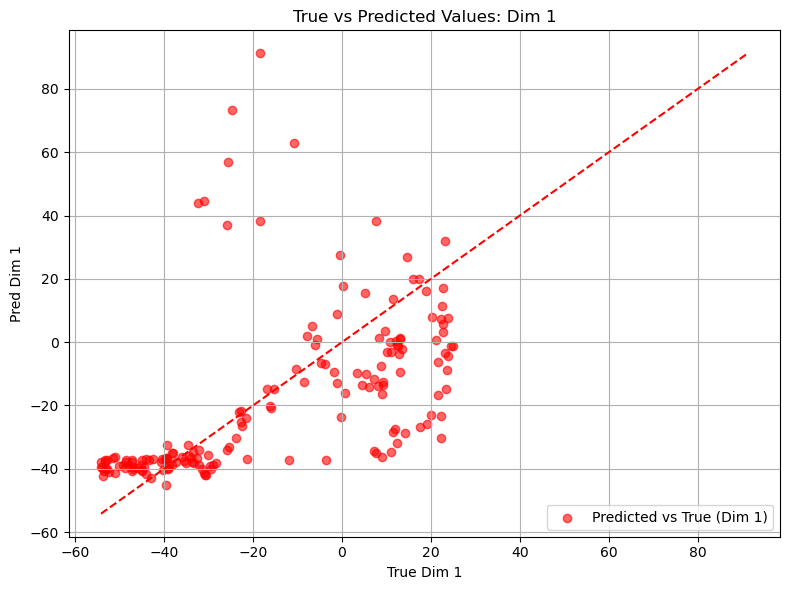

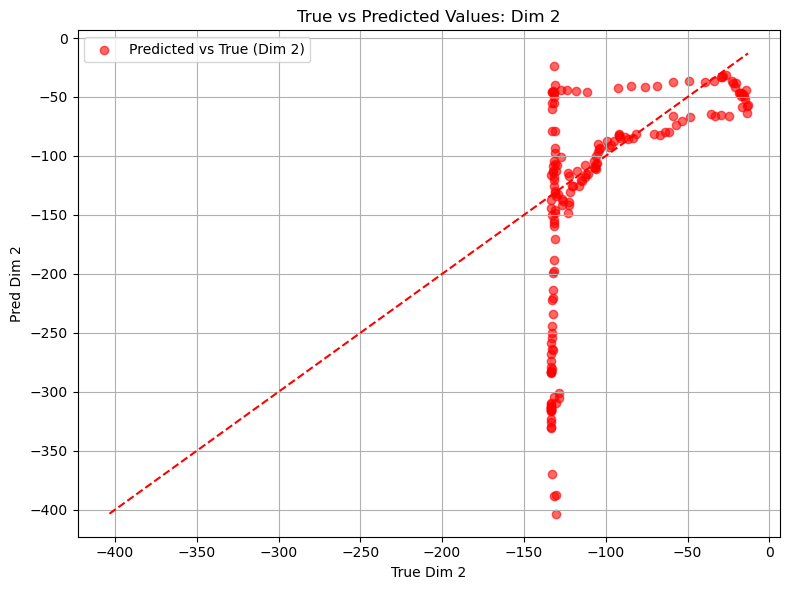

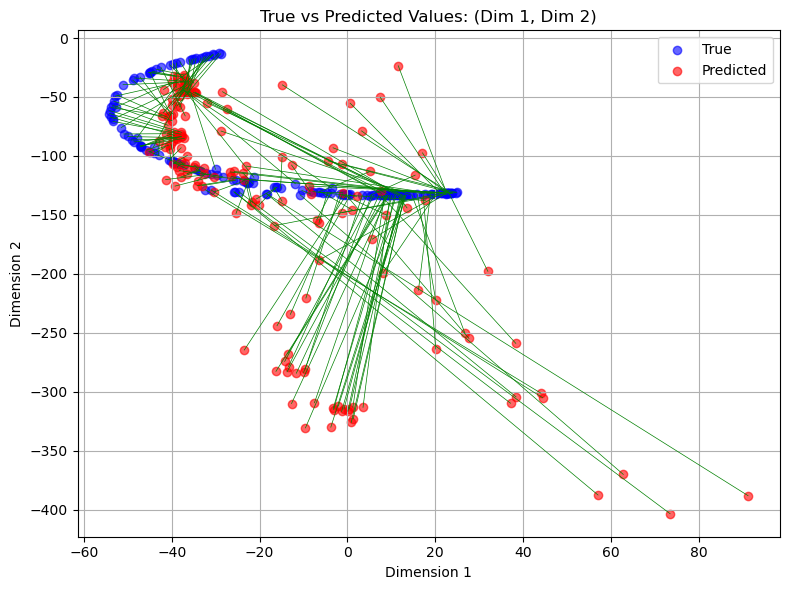

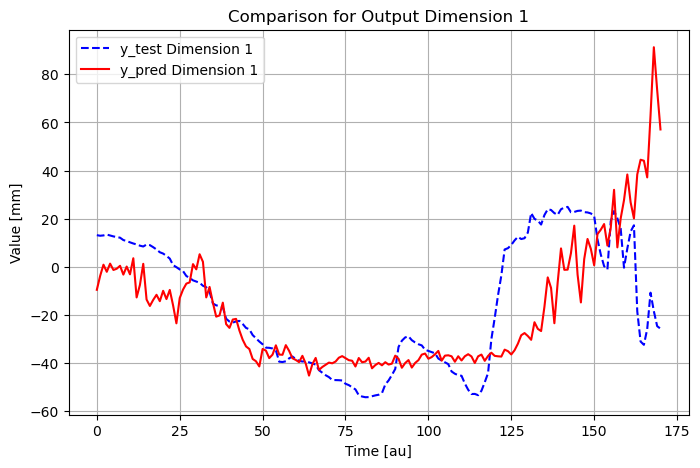

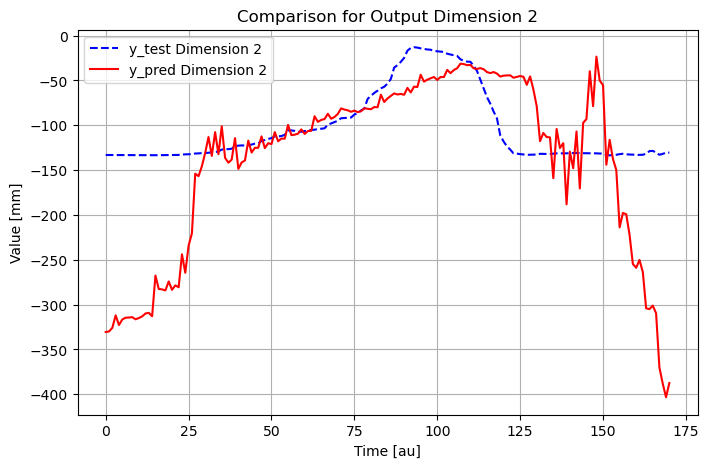

In [10]:
y_pred = model.predict(x_test)
y_test_denormalised = my_bar.denormalize(y_test, y_means, y_stds)
y_pred_denormalised = my_bar.denormalize(y_pred, y_means, y_stds)
my_bar.print_mse(y_test_denormalised, y_pred_denormalised)
my_bar.plot_data(y_test_denormalised, y_pred_denormalised)